In [1]:
import pymc as pm; import arviz as az; import sys; import numpy as np; import pickle; import pytensor 
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.config import kb_eV, T, kb_J, h, F, N_A
from _CO_Oxidation import wrapper_acid as wp
from _CO_Oxidation.wrapper_acid import plot_posteriors, plot_model_fits, plot_coverages, plot_drc, simulate_fake_data

C_H_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
experiments_data = pickle.load(open('import_Pt100_acid.pkl', 'rb'))
wp.process_experimental_data(experiments_data, C_H_list, P_CO_list)
E_in = wp.E_in; P_CO_in = wp.P_CO_in; C_H_in = wp.C_H_in

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    sigma_rel = pm.HalfNormal('sigma_rel', sigma=0.1) # 0.1
    rate = pm.LogNormal('rate', mu=log_rate, sigma=sigma_rel, observed=wp.rate_obs_matrix)
    return rate

Ru_comp = 0.0

# LH

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.66,7
,3000,0,0.62,7
,3000,0,0.54,7
,3000,0,0.57,7


Computed from 4000 posterior samples and 490 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   609.87    53.64
p_loo        7.62        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      490  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



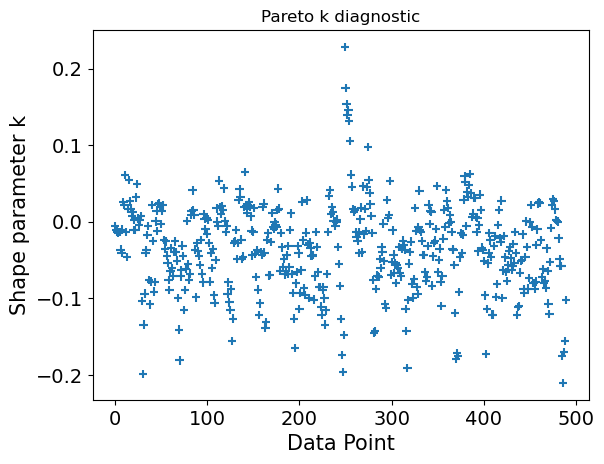

Sampling: [Gact2_0, deltaG1_0, deltaG4_0, sigma_rel]


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.157  0.004  -0.165   -0.150      0.000    0.000    1503.0    1663.0    1.0
deltaG4_0  0.827  0.004   0.820    0.833      0.000    0.000    1511.0    1784.0    1.0
Gact2_0    0.713  0.002   0.709    0.716      0.000    0.000    1921.0    2461.0    1.0
sigma_rel  1.336  0.032   1.276    1.395      0.001    0.001    3412.0    2927.0    1.0

--- Prior-to-Posterior Contraction ---
deltaG1_0: 1.000
deltaG4_0: 1.000
Gact2_0: 1.000
sigma_rel: 0.714


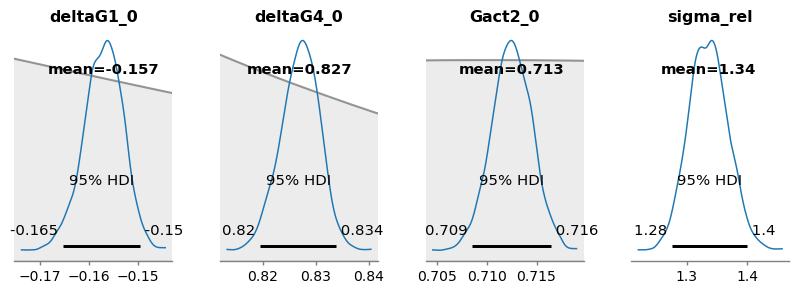

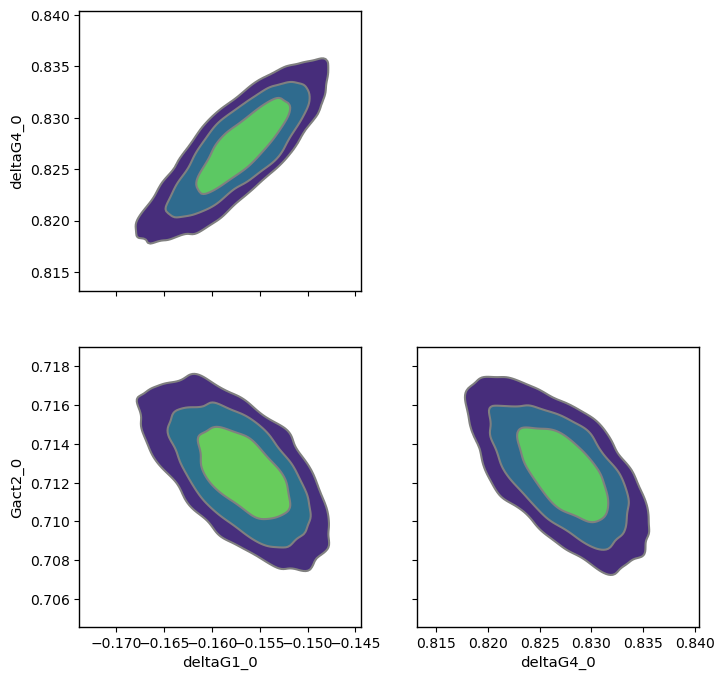

Sampling: [rate]


rate: 0.503


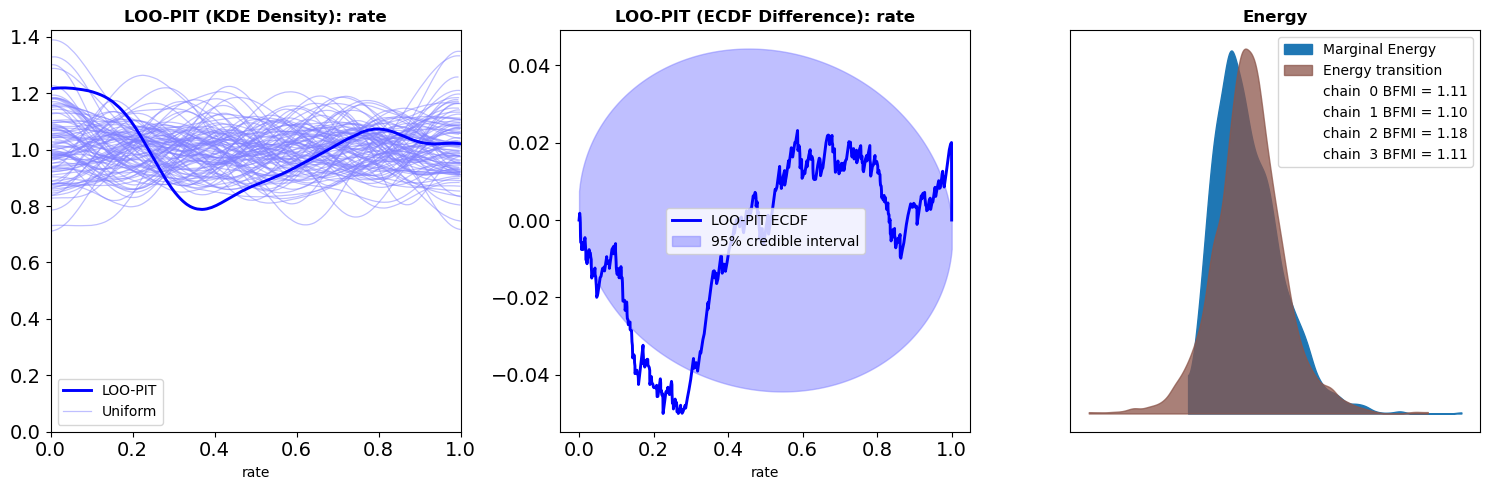

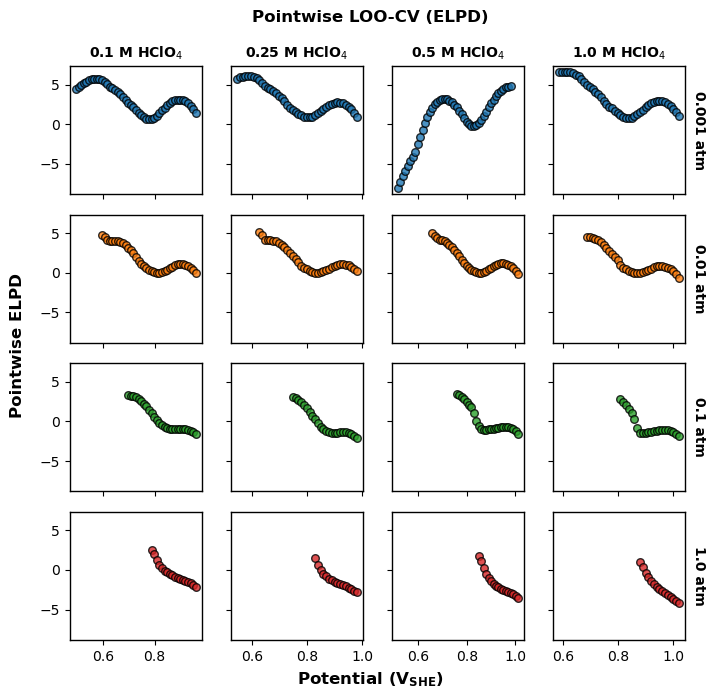

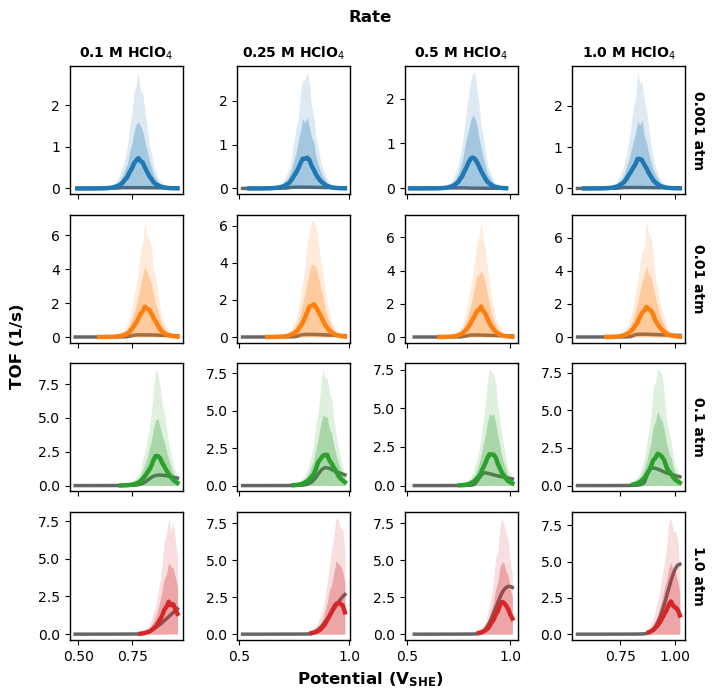

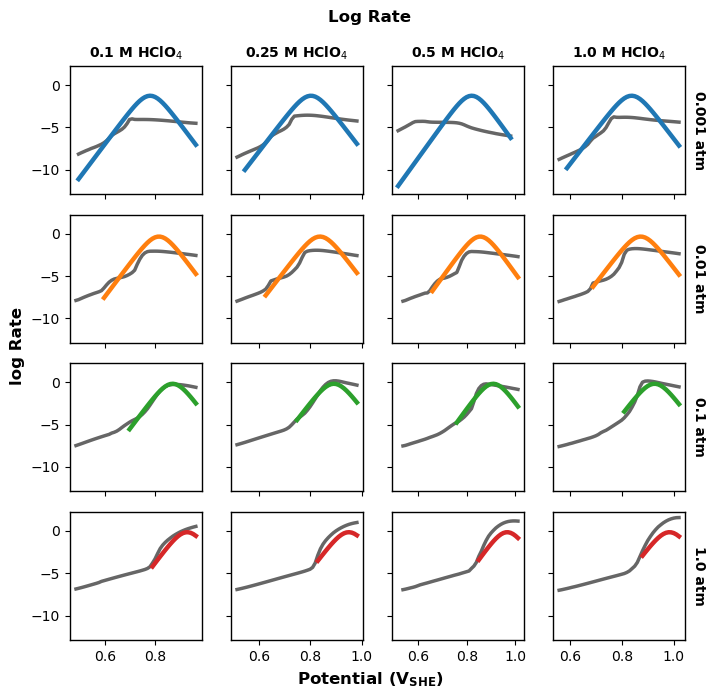

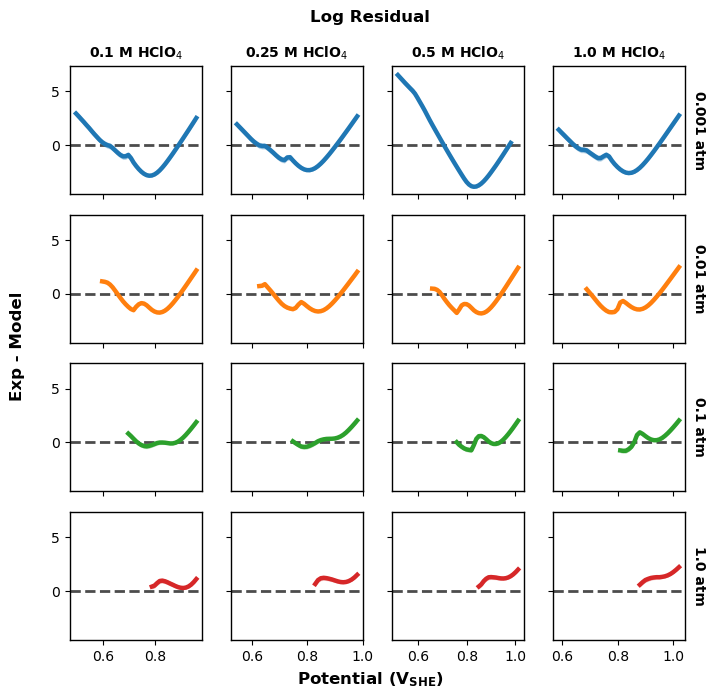

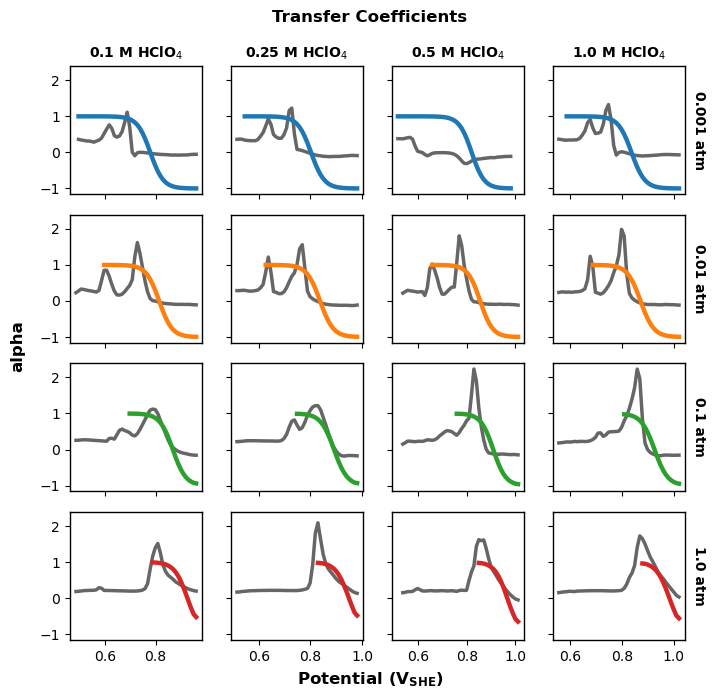

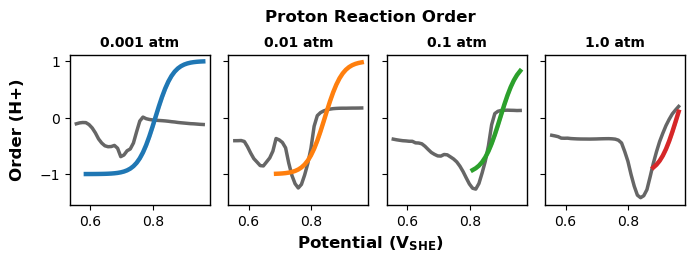

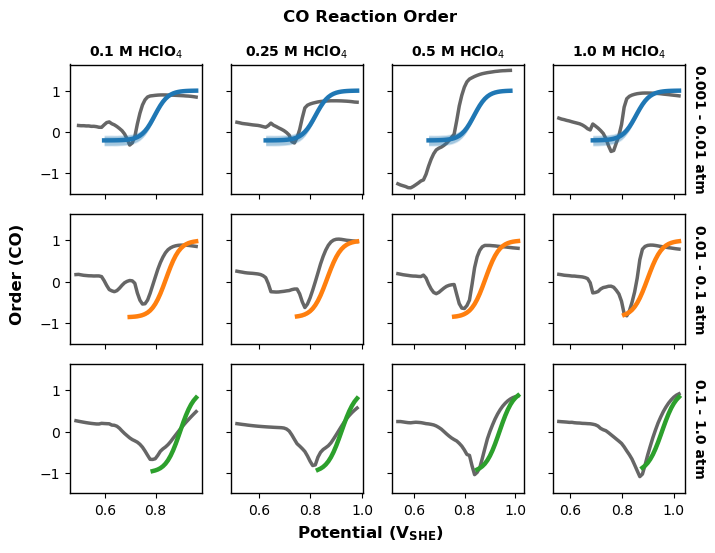

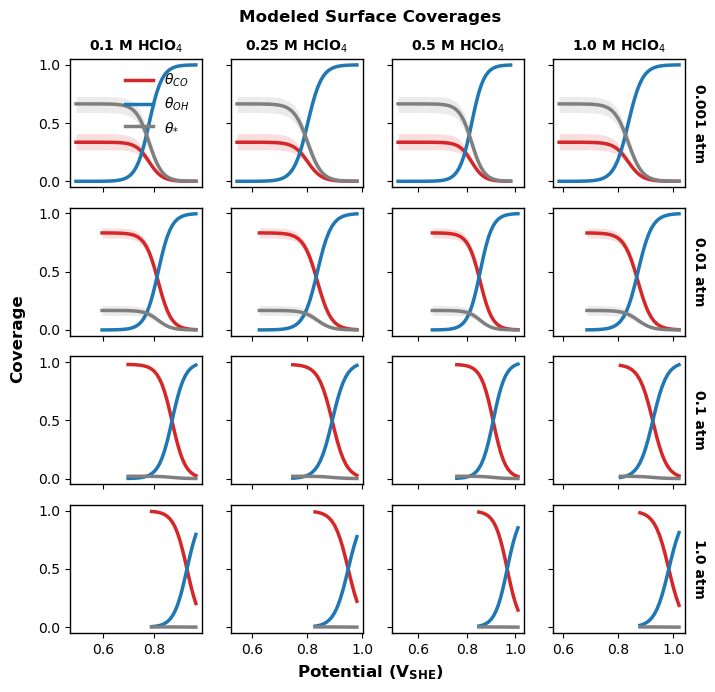

In [2]:
with pm.Model() as LH:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.7, sigma=0.2, lower=0.0)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH
    rate = observables(log_rate) 

trace_LH, loo_LH = fit_and_evaluate(LH)

ppc_LH = plot_posteriors(trace_LH, LH)
plot_model_fits(trace_LH, ppc_LH, loo_LH); plot_coverages(trace_LH)

# ER

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.09,63
,3000,0,0.10,95
,3000,0,0.09,71
,3000,0,0.10,259


Computed from 4000 posterior samples and 490 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   881.38    49.22
p_loo        6.00        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      490  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



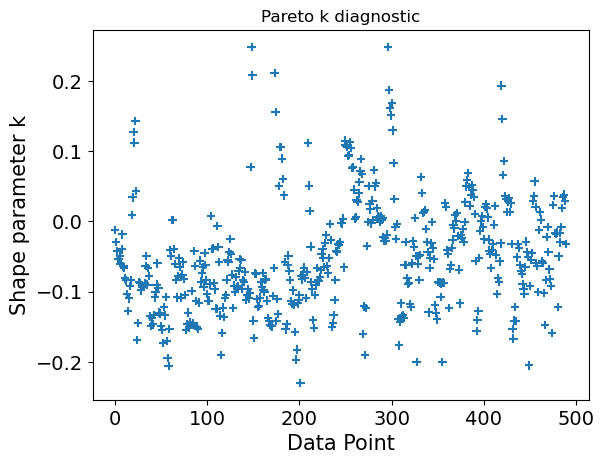

Sampling: [Gact2_0, beta_2, deltaG1_0, deltaG4_0, sigma_rel]


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.494  0.145  -0.717   -0.182      0.007    0.004     480.0     426.0   1.01
deltaG4_0  0.521  0.146   0.291    0.833      0.007    0.004     479.0     409.0   1.01
Gact2_0    1.233  0.010   1.215    1.251      0.000    0.000     928.0     459.0   1.00
beta_2     0.529  0.013   0.507    0.553      0.000    0.000     952.0     533.0   1.00
sigma_rel  0.857  0.024   0.811    0.902      0.000    0.000    3022.0    2409.0   1.00

--- Prior-to-Posterior Contraction ---
deltaG1_0: 0.462
deltaG4_0: 0.459
Gact2_0: 0.998
beta_2: 0.993
sigma_rel: 0.839


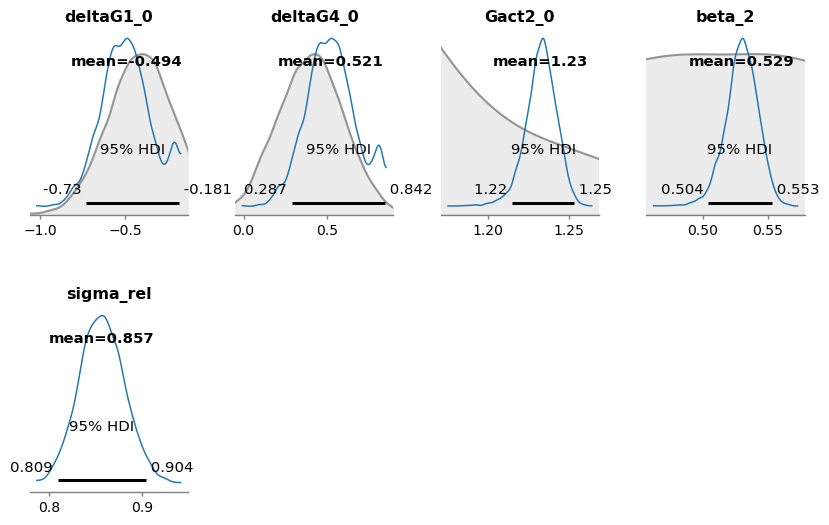

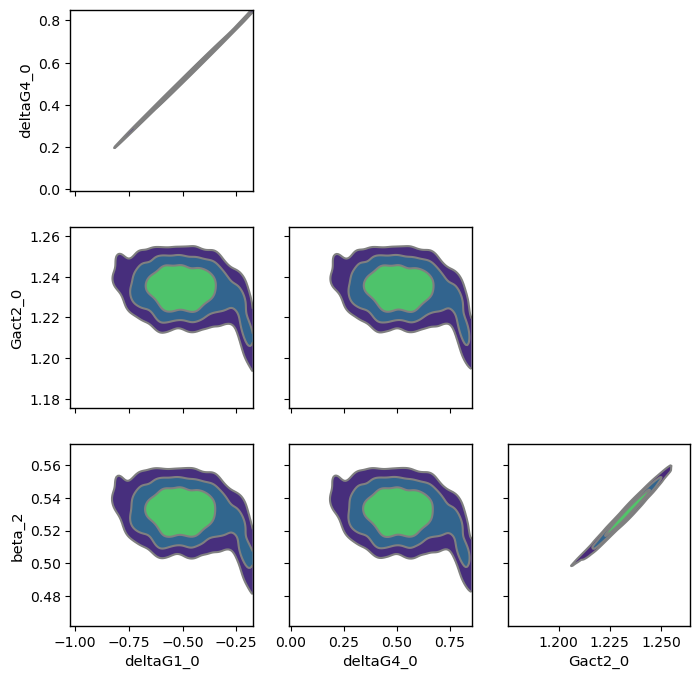

Sampling: [rate]


rate: 0.642


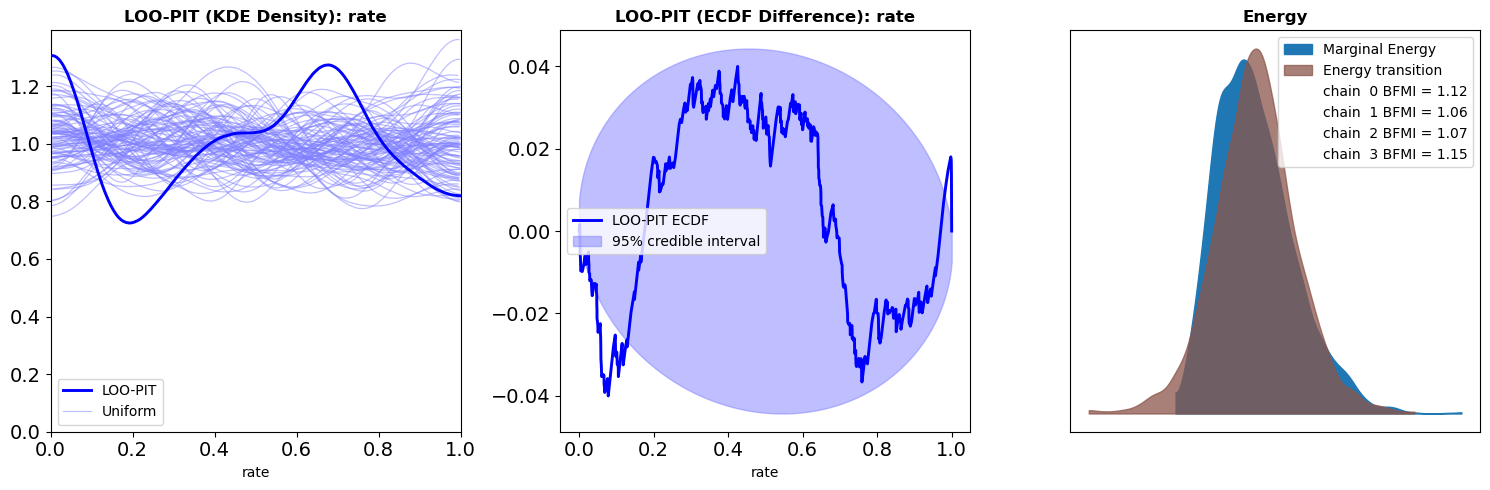

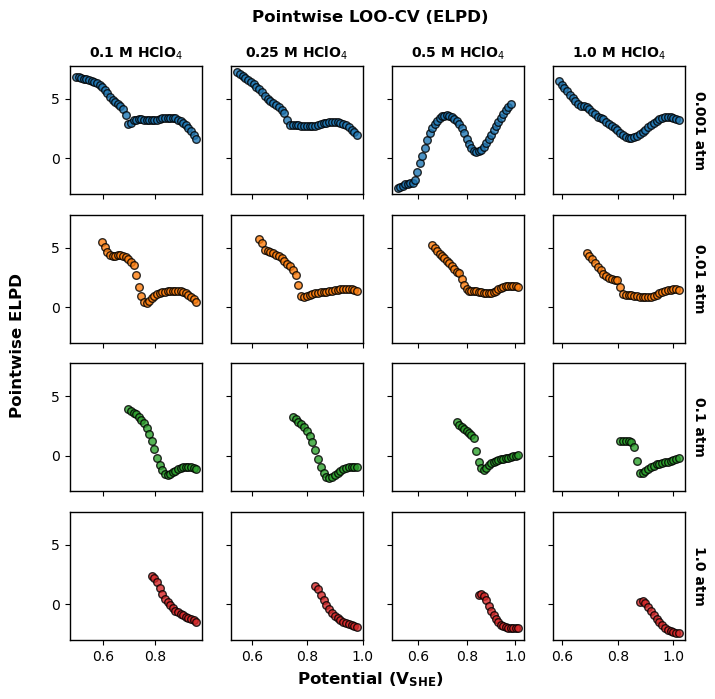

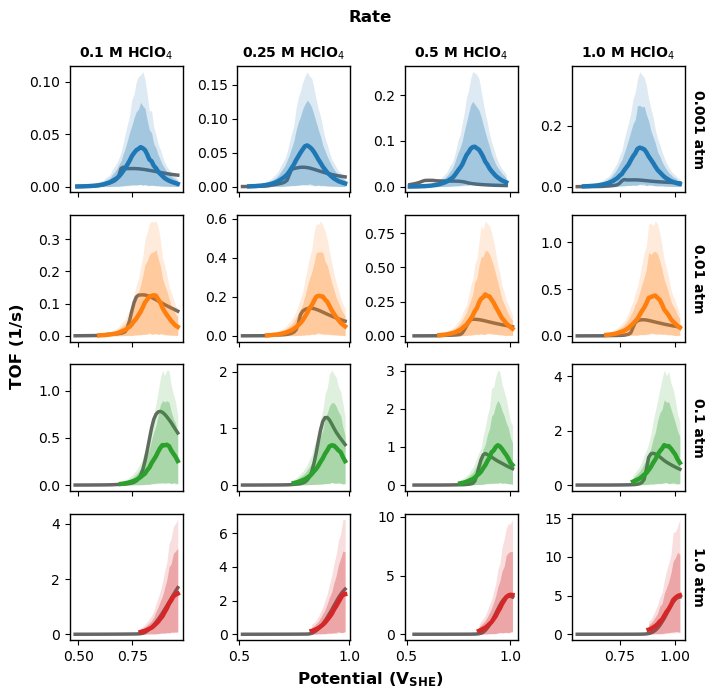

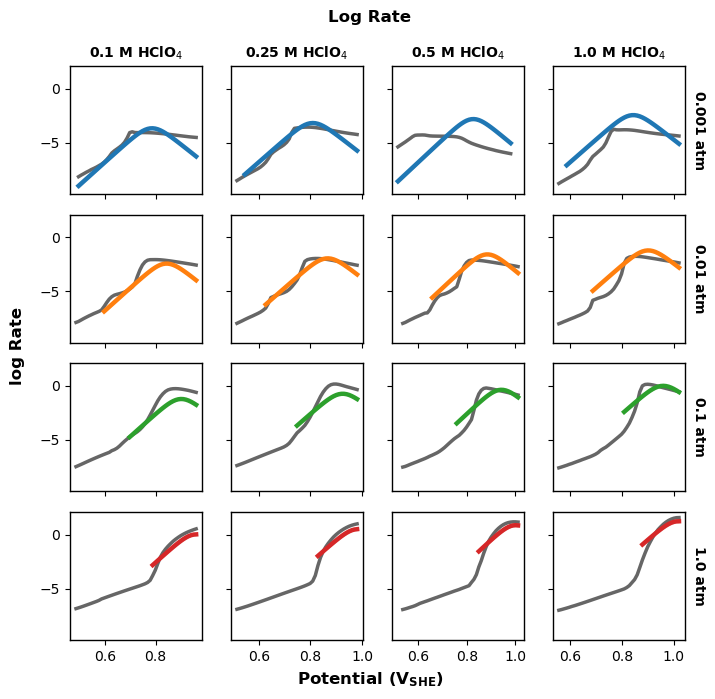

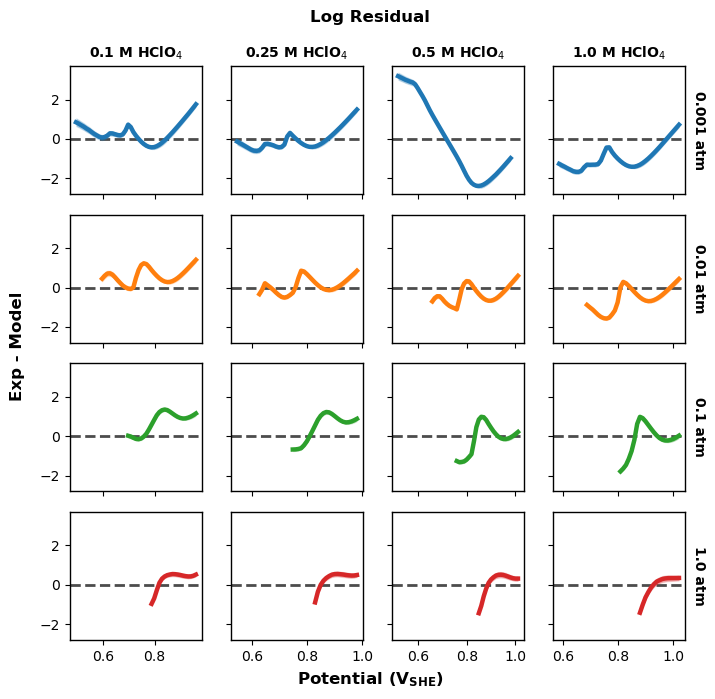

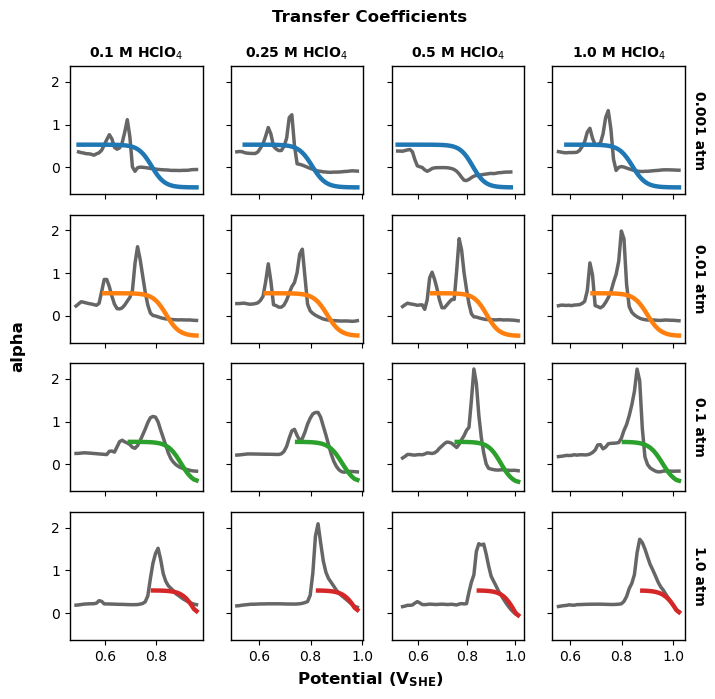

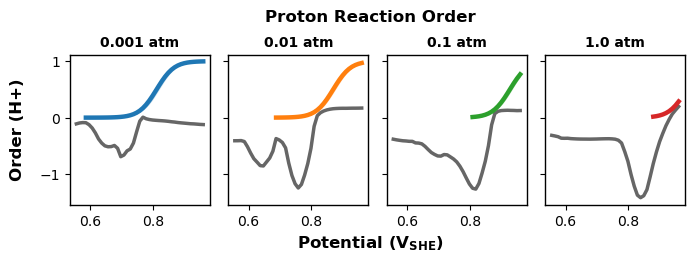

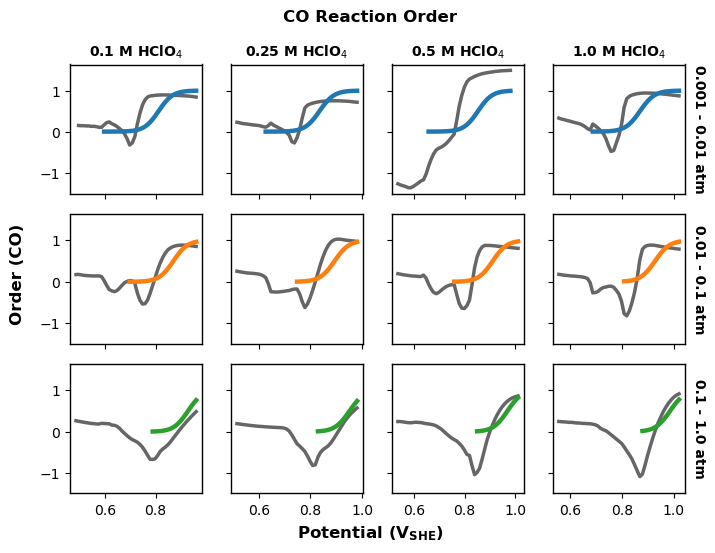

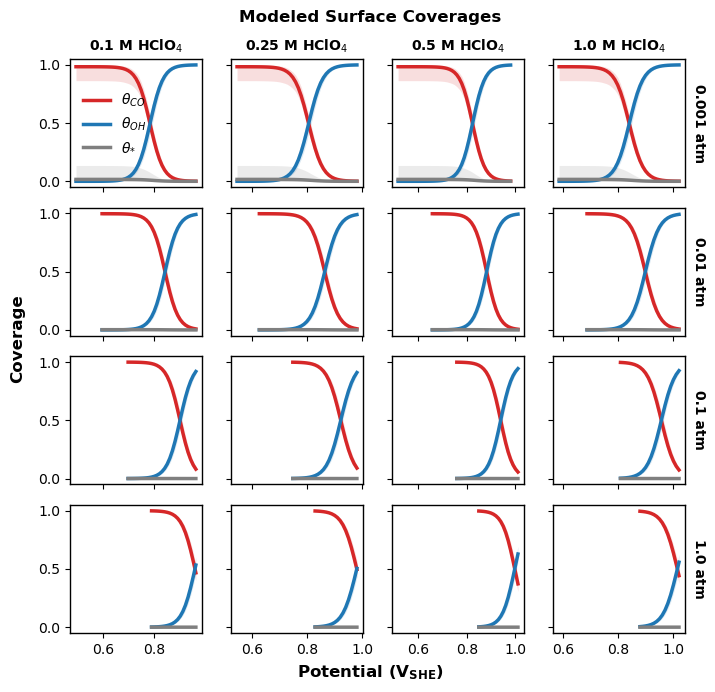

In [3]:
with pm.Model() as ER:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + H2O -> COOH* + H+ + (e-) (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)  
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO
    rate = observables(log_rate) 

trace_ER, loo_ER = fit_and_evaluate(ER)

ppc_ER = plot_posteriors(trace_ER, ER)
plot_model_fits(trace_ER, ppc_ER, loo_ER); plot_coverages(trace_ER)

# ER LH 2

In [ ]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + H2O -> COOH* + H+ + (e-) (RDS)
    2b. CO* + OH* -> COOH* + * (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)  
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2) # at 0V_SHE
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_LH = Gact2_LH_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate_ER = log_k2_ER + log_theta_CO 
    log_rate = pt.logaddexp(log_rate_LH, log_rate_ER)
    rate = observables(log_rate) 

trace_ER_LH_2, loo_ER_LH_2 = fit_and_evaluate(ER_2)

ppc_ER_LH_2 = plot_posteriors(trace_ER_LH_2, ER_2)
plot_model_fits(trace_ER_LH_2, ppc_ER_LH_2); plot_coverages(trace_ER_LH_2)
plot_drc(ER_2, trace_ER_LH_2, perturb_vars=['Gact2_LH_0', 'Gact2_ER_0'], perturb_labels=['LH', 'ER'], 
         var_types={'Gact2_LH_0': 'Gact', 'Gact2_ER_0': 'Gact'})

# LH 2 4

In [ ]:
with pm.Model() as LH_2_4:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (SSA)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (SSA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.8, sigma=0.05)
    beta_4 = pm.Beta('beta_4', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)
    Gact4_0 = pm.Normal('Gact4_0', mu=1.2, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0
    Gact4 = Gact4_0 - beta_4*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k4 = np.log(kb_J*T/h) - Gact4/(kb_eV*T)
    log_k_minus4 = log_k4 - log_K4

    K1_Pco = pt.exp(log_K1 + np.log(P_CO_in))
    A = 1.0 + K1_Pco
    B = pt.exp(log_k_minus4 + np.log(C_H_in))
    C = pt.exp(log_k2) * K1_Pco
    k4_lin = pt.exp(log_k4)
    a_quad = A * C
    b_quad = (A * B) + k4_lin - C
    c_quad = -B
    theta_empty_lin = (-b_quad + pt.sqrt(b_quad**2 - 4 * a_quad * c_quad)) / (2 * a_quad)
    log_theta = pt.log(theta_empty_lin)
    log_theta_CO = log_K1 + np.log(P_CO_in) + log_theta
    log_denominator = pt.logsumexp(pt.stack([log_k_minus4 + np.log(C_H_in), log_k2 + log_theta_CO]), axis=0)
    log_theta_OH = log_k4 + log_theta - log_denominator

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', theta_empty_lin)

    log_rate = log_k2 + log_theta_CO + log_theta_OH
    rate = observables(log_rate) 

trace_LH_2_4, loo_LH_2_4 = fit_and_evaluate(LH_2_4)

ppc_LH_2_4 = plot_posteriors(trace_LH_2_4, LH_2_4)
plot_model_fits(trace_LH_2_4, ppc_LH_2_4); plot_coverages(trace_LH_2_4)
plot_drc(LH_2_4, trace_LH_2_4, perturb_vars=['Gact2_0', 'Gact4_0'], perturb_labels=['LH', 'OH ads'], 
         var_types={'Gact2_0': 'Gact', 'Gact4_0': 'Gact'})

# LH PCT

In [ ]:
with pm.Model() as LH_PCT:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)* -> COOH* + * + (1-q)(e-) (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH(q-1)* + H+ + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)
    q = pm.Beta('q', alpha=1, beta=1)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q*E_in
    Gact2 = Gact2_0 - beta_2*(1-q)*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH
    rate = observables(log_rate) 

trace_LH_PCT, loo_LH_PCT = fit_and_evaluate(LH_PCT)

ppc_LH_PCT = plot_posteriors(trace_LH_PCT, LH_PCT)
plot_model_fits(trace_LH_PCT, ppc_LH_PCT); plot_coverages(trace_LH_PCT)

# LH ER PCT

In [ ]:
with pm.Model() as LH_ER_PCT:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)* -> COOH* + * + (1-q)(e-) (RDS)
    2b. CO* + H2O -> COOH* + H+ + (e-) (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH(q-1)* + H+ + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2_LH = pm.Beta('beta_2_LH', alpha=5, beta=5)
    beta_2_ER = pm.Beta('beta_2_ER', alpha=5, beta=5)
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2)
    q = pm.Beta('q', alpha=1, beta=1)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q*E_in
    Gact2_LH = Gact2_LH_0 - beta_2_LH*(1-q)*E_in
    Gact2_ER = Gact2_ER_0 - beta_2_ER*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate_ER = log_k2_ER + log_theta_CO 
    log_rate = pt.logaddexp(log_rate_LH, log_rate_ER)
    rate = observables(log_rate) 

trace_LH_ER_PCT, loo_LH_ER_PCT = fit_and_evaluate(LH_ER_PCT)

ppc_LH_ER_PCT = plot_posteriors(trace_LH_ER_PCT, LH_ER_PCT)
plot_model_fits(trace_LH_ER_PCT, ppc_LH_ER_PCT); plot_coverages(trace_LH_ER_PCT)
plot_drc(LH_ER_PCT, trace_LH_ER_PCT, perturb_vars=['Gact2_LH_0', 'Gact2_ER_0'], perturb_labels=['LH', 'ER'], 
         var_types={'Gact2_LH_0': 'Gact', 'Gact2_ER_0': 'Gact'})

# LH PCT 4

In [ ]:
with pm.Model() as LH_PCT_4:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)* -> COOH* + * + (1-q)(e-) (SSA)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH(q-1)* + H+ + (q)(e-) (SSA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)
    q = pm.Beta('q', alpha=1, beta=1)
    beta_4 = pm.Beta('beta_4', alpha=5, beta=5)
    Gact4_0 = pm.Normal('Gact4_0', mu=1.0, sigma=0.2)

    # Thermodynamics
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q*E_in
    Gact2 = Gact2_0 - beta_2*(1-q)*E_in
    Gact4 = Gact4_0 - beta_4*q*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k4f = np.log(kb_J*T/h) - Gact4/(kb_eV*T)
    log_k4b = log_k4f - log_K4

    K1_PCO = pt.exp(log_K1) * P_CO_in
    k2 = pt.exp(log_k2)
    k4f = pt.exp(log_k4f)
    k4b = pt.exp(log_k4b)
    A = 1.0 + K1_PCO
    B = k4b * C_H_in
    C_coeff = k2 * K1_PCO
    a = A * C_coeff
    b = A * B + k4f - C_coeff
    c = -B
    
    theta_empty = pm.Deterministic('theta_empty', (2.0 * (-c)) / (b + pt.sqrt(b**2 - 4.0 * a * c)))
    theta_CO = pm.Deterministic('theta_CO', K1_PCO * theta_empty)
    theta_OH = pm.Deterministic('theta_OH', (k4f * theta_empty) / (B + C_coeff * theta_empty))

    # Rate expression
    log_rate = log_k2 + pt.log(theta_CO) + pt.log(theta_OH)
    rate = observables(log_rate) 

trace_LH_PCT_4, loo_LH_PCT_4 = fit_and_evaluate(LH_PCT_4)

ppc_LH_PCT_4 = plot_posteriors(trace_LH_PCT_4, LH_PCT_4)
plot_model_fits(trace_LH_PCT_4, ppc_LH_PCT_4); plot_coverages(trace_LH_PCT_4)
plot_drc(LH_PCT_4, trace_LH_PCT_4, perturb_vars=['Gact2_0', 'Gact4_0'], perturb_labels=['LH', 'OH ads'], 
         var_types={'Gact2_0': 'Gact', 'Gact4_0': 'Gact'})

# LH PCT 1

In [ ]:
with pm.Model() as LH_PCT_1:
    '''
    1. CO + * <-> CO* (SSA)
    2. CO* + OH(q-1)* -> COOH* + * + (1-q)(e-) (SSA)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH(q-1)* + H+ + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact1_0 = pm.Normal('Gact1_0', mu=0.7, sigma=0.2) 
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)
    q = pm.Beta('q', alpha=1, beta=1)

    # Thermodynamics
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q*E_in
    Gact1 = Gact1_0 
    Gact2 = Gact2_0 - beta_2*(1-q)*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1f = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    
    log_k1b = log_k1f - log_K1
    K4_prime = pt.exp(log_K4) / C_H_in
    k1f_PCO = pt.exp(log_k1f) * P_CO_in
    k1b = pt.exp(log_k1b)
    k2 = pt.exp(log_k2)
    A = 1.0 + K4_prime
    a = A * k2 * K4_prime
    b = A * k1b + k1f_PCO - k2 * K4_prime
    c = -k1b
    theta_empty = pm.Deterministic('theta_empty', (2.0 * (-c)) / (b + pt.sqrt(b**2 - 4.0 * a * c)))
    theta_OH = pm.Deterministic('theta_OH', K4_prime * theta_empty)
    theta_CO = pm.Deterministic('theta_CO', (k1f_PCO * theta_empty) / (k1b + k2 * theta_OH))

    # Rate expression
    log_rate = log_k2 + pt.log(theta_CO) + pt.log(theta_OH)
    rate = observables(log_rate) 

trace_LH_PCT_1, loo_LH_PCT_1 = fit_and_evaluate(LH_PCT_1)

ppc_LH_PCT_1 = plot_posteriors(trace_LH_PCT_1, LH_PCT_1)
plot_model_fits(trace_LH_PCT_1, ppc_LH_PCT_1); plot_coverages(trace_LH_PCT_1)
plot_drc(LH_PCT_1, trace_LH_PCT_1, perturb_vars=['Gact2_0', 'Gact1_0'], perturb_labels=['LH', 'CO ads'], 
         var_types={'Gact2_0': 'Gact', 'Gact1_0': 'Gact'})

# LH ER PCT 1

In [ ]:
with pm.Model() as LH_ER_PCT_1:
    '''
    1. CO + * <-> CO* (SSA)
    2a. CO* + OH(q-1)* -> COOH* + * + (1-q)(e-) (SSA)
    2b. CO* + H2O -> COOH* + H+ + (e-) (SSA)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH(q-1)* + H+ + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2_LH = pm.Beta('beta_2_LH', alpha=5, beta=5)
    beta_2_ER = pm.Beta('beta_2_ER', alpha=5, beta=5)
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact1_0 = pm.Normal('Gact1_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q*E_in
    Gact2_LH = Gact2_LH_0 - beta_2_LH*(1-q)*E_in
    Gact2_ER = Gact2_ER_0 - beta_2_ER*E_in
    Gact1 = Gact1_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1f = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k1b = log_k1f - log_K1

    K4_prime = pt.exp(log_K4) / C_H_in
    k1f_PCO = pt.exp(log_k1f) * P_CO_in
    k1b = pt.exp(log_k1b)
    k2_LH = pt.exp(log_k2_LH)
    k2_ER = pt.exp(log_k2_ER)
    A = 1.0 + K4_prime
    a = A * k2_LH * K4_prime
    b = A * (k1b + k2_ER) + k1f_PCO - k2_LH * K4_prime
    c = -(k1b + k2_ER)
    
    theta_empty = pm.Deterministic('theta_empty', (2.0 * (-c)) / (b + pt.sqrt(b**2 - 4.0 * a * c)))
    theta_OH = pm.Deterministic('theta_OH', K4_prime * theta_empty)
    theta_CO = pm.Deterministic('theta_CO', (k1f_PCO * theta_empty) / (k1b + k2_ER + k2_LH * theta_OH))

    # Rate expression
    log_rate_LH = log_k2_LH + pt.log(theta_CO) + pt.log(theta_OH)
    log_rate_ER = log_k2_ER + pt.log(theta_CO) 
    log_rate = pt.logaddexp(log_rate_LH, log_rate_ER)
    rate = observables(log_rate)

trace_LH_ER_PCT_1, loo_LH_ER_PCT_1 = fit_and_evaluate(LH_ER_PCT_1)

ppc_LH_ER_PCT_1 = plot_posteriors(trace_LH_ER_PCT_1, LH_ER_PCT_1)
plot_model_fits(trace_LH_ER_PCT_1, ppc_LH_ER_PCT_1); plot_coverages(trace_LH_ER_PCT_1)
plot_drc(LH_ER_PCT_1, trace_LH_ER_PCT_1, perturb_vars=['Gact2_LH_0', 'Gact2_ER_0', 'Gact1_0'], perturb_labels=['LH', 'ER', 'CO ads'], 
         var_types={'Gact2_LH_0': 'Gact', 'Gact2_ER_0': 'Gact', 'Gact1_0': 'Gact'})

# Comparison

    rank    elpd_loo     p_loo   elpd_diff        weight         se        dse  warning scale
ER     0  881.378412  5.999114    0.000000  1.000000e+00  49.218811   0.000000    False   log
LH     1  609.871451  7.615422  271.506961  1.106201e-09  53.635748  17.024441    False   log


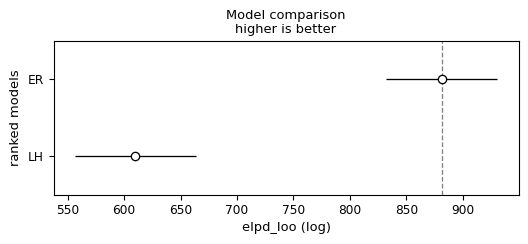

In [4]:
comparison_dict = {
    "LH": loo_LH,
    "ER": loo_ER,
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()